Loaded shape: (1000, 28)


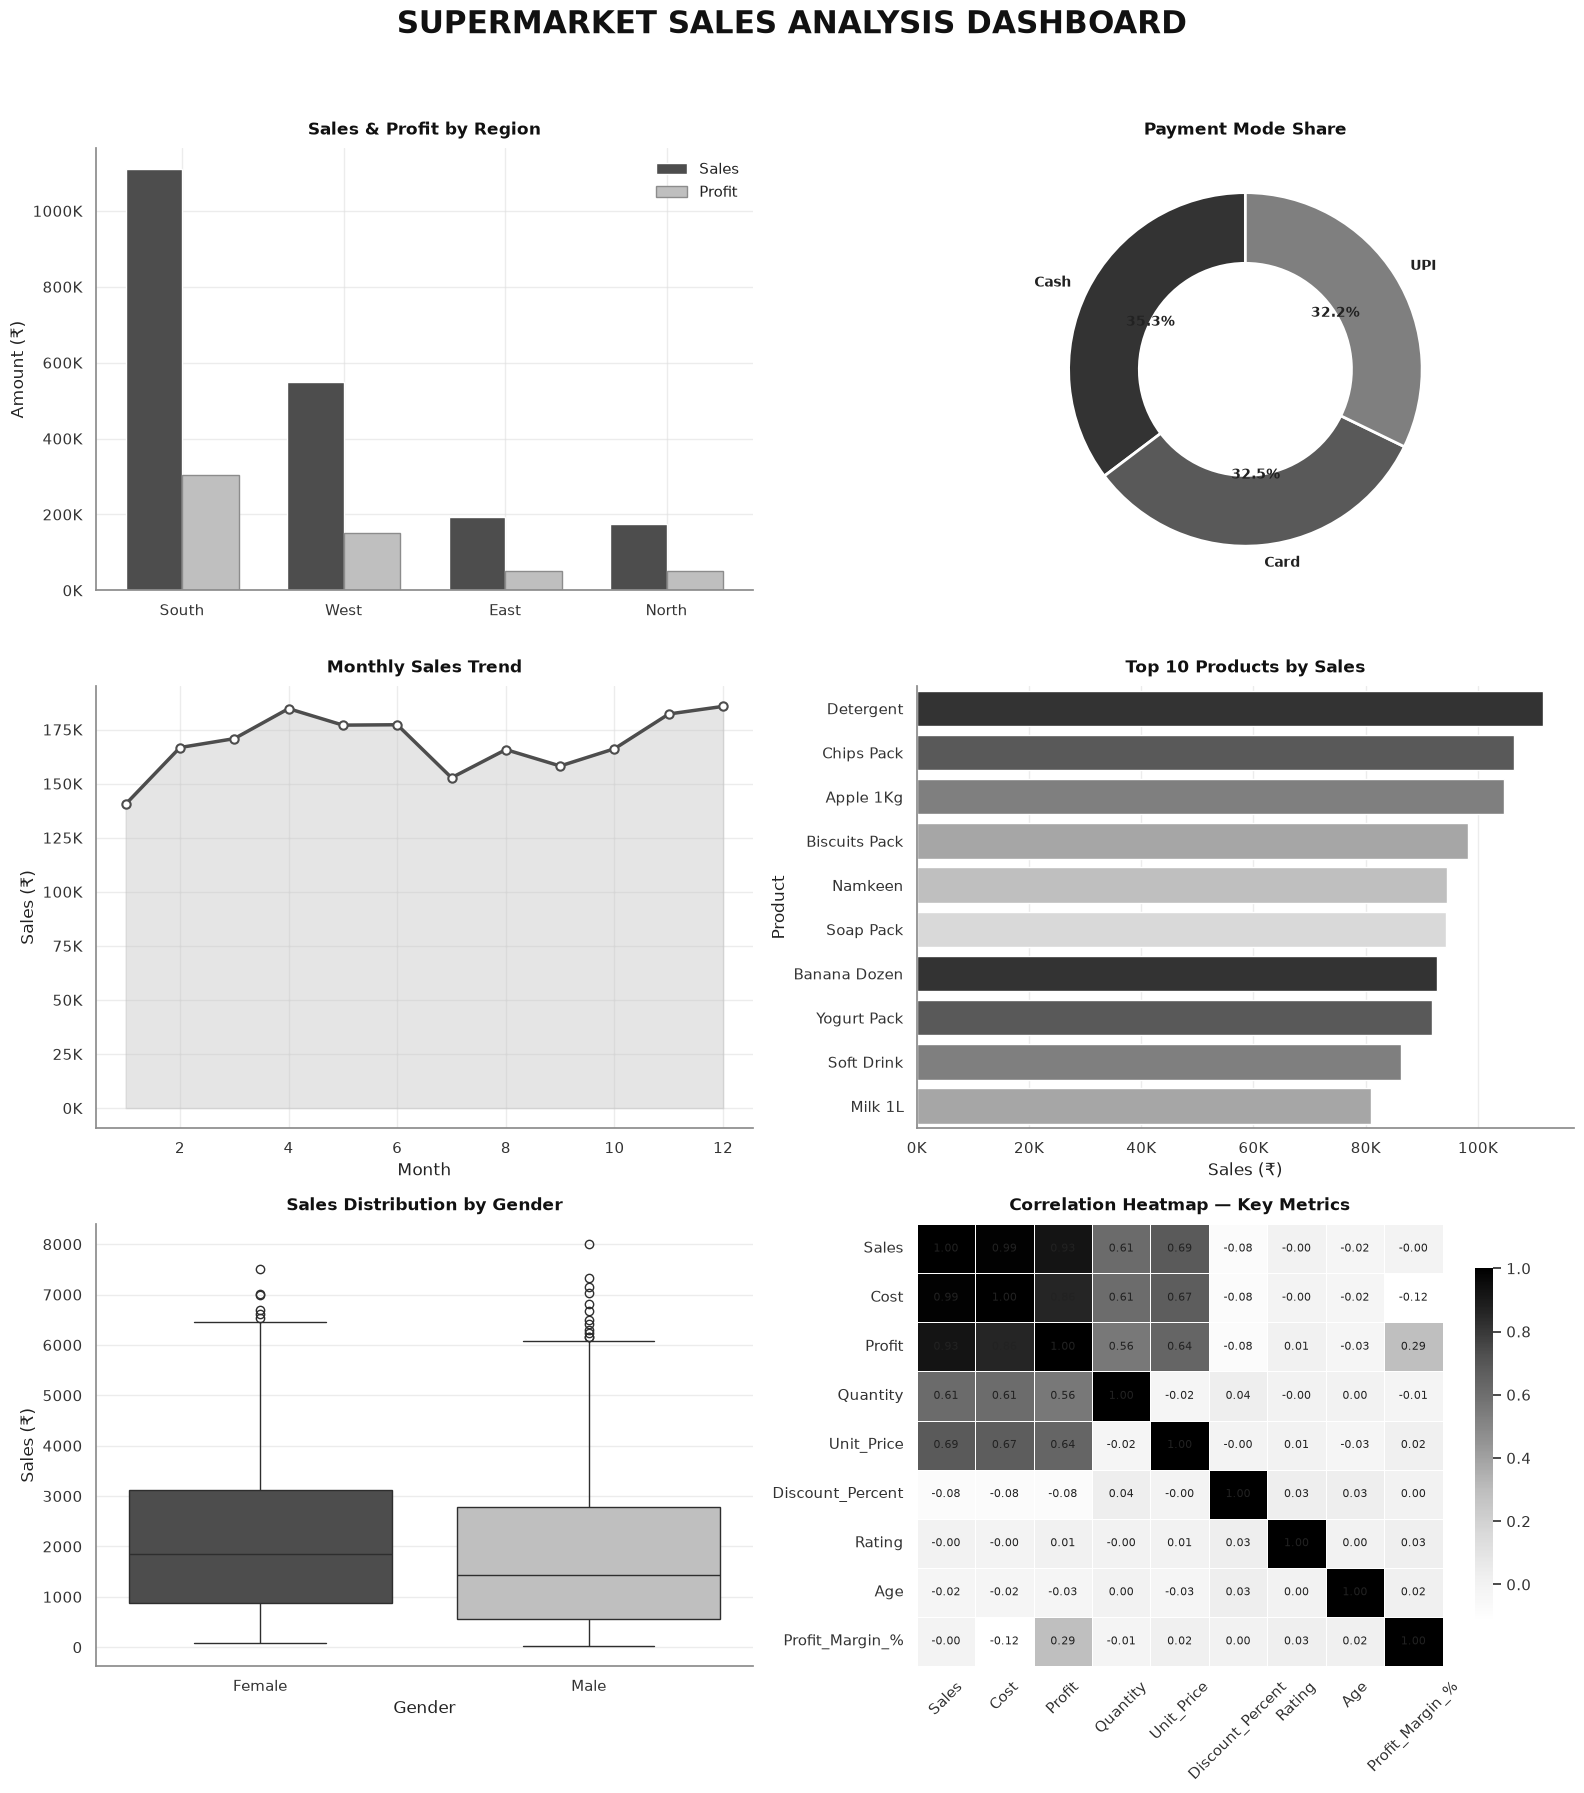


Combined dashboard saved to: C:\Users\Gowsalya\supermarket_dashboard.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


INPUT_FILE = r"C:\Users\Gowsalya\SuperMarket_Cleaned.csv"
OUTPUT_PNG = r"C:\Users\Gowsalya\supermarket_dashboard.png"


# 1. LOAD DATA
df = pd.read_csv(INPUT_FILE)
print(f"Loaded shape: {df.shape}")


# 2. THEME SETUP — white background, grey charts
GREY_DARK = "#4d4d4d"
GREY_MED = "#8c8c8c"
GREY_LIGHT = "#bfbfbf"
GREY_PALETTE = ["#333333", "#595959", "#7f7f7f", "#a6a6a6", "#bfbfbf", "#d9d9d9"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GREY_MED,
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#111111",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "text.color": "#222222",
    "grid.color": "#e0e0e0",
    "grid.alpha": 0.6,
    "font.family": "DejaVu Sans",
})


def style_ax(ax, title):
    ax.set_title(title, pad=10)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    return ax


# 3. BUILD SINGLE FIGURE — 3 rows x 2 cols
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("SUPERMARKET SALES ANALYSIS DASHBOARD", fontsize=22,
             fontweight="bold", color="#111111", y=0.995)


# [0,0] MATPLOTLIB — Region-wise Sales & Profit (grouped bar)

ax = axes[0, 0]
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
x = range(len(region_summary))
width = 0.35
ax.bar([i - width/2 for i in x], region_summary["Sales"], width, label="Sales", color=GREY_DARK)
ax.bar([i + width/2 for i in x], region_summary["Profit"], width, label="Profit",
       color=GREY_LIGHT, edgecolor=GREY_MED)
ax.set_xticks(list(x))
ax.set_xticklabels(region_summary.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
ax.set_ylabel("Amount (₹)")
ax.legend(frameon=False)
style_ax(ax, "Sales & Profit by Region")


# [0,1] MATPLOTLIB — Payment Mode Share (donut chart)

ax = axes[0, 1]
pay_counts = df["Payment_Mode"].value_counts()
ax.pie(
    pay_counts.values, labels=pay_counts.index, autopct="%1.1f%%",
    startangle=90, colors=GREY_PALETTE[:len(pay_counts)],
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2},
    textprops={"color": "#222222", "fontsize": 10, "fontweight": "bold"},
)
ax.set_title("Payment Mode Share", pad=10)


# [1,0] MATPLOTLIB — Monthly Sales Trend (line + fill)

ax = axes[1, 0]
monthly = df.groupby("Order_Month")["Sales"].sum().sort_index()
ax.plot(monthly.index, monthly.values, marker="o", color=GREY_DARK,
        linewidth=2.5, markersize=6, markerfacecolor="white",
        markeredgecolor=GREY_DARK, markeredgewidth=1.5)
ax.fill_between(monthly.index, monthly.values, color=GREY_LIGHT, alpha=0.4)
ax.set_xlabel("Month")
ax.set_ylabel("Sales (₹)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
style_ax(ax, "Monthly Sales Trend")


# [1,1] SEABORN — Top 10 Products by Sales (horizontal bar)
ax = axes[1, 1]
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index,
            ax=ax, palette=sns.color_palette(GREY_PALETTE * 2, len(top_products)),
            legend=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
ax.set_xlabel("Sales (₹)")
ax.set_ylabel("Product")
style_ax(ax, "Top 10 Products by Sales")


# [2,0] SEABORN — Sales Distribution by Gender (boxplot)
ax = axes[2, 0]
sns.boxplot(data=df, x="Gender", y="Sales", hue="Gender", ax=ax,
            palette=[GREY_DARK, GREY_LIGHT], legend=False)
ax.set_ylabel("Sales (₹)")
style_ax(ax, "Sales Distribution by Gender")

# [2,1] SEABORN — Correlation Heatmap of key numeric fields
ax = axes[2, 1]
numeric_cols = [c for c in ["Sales", "Cost", "Profit", "Quantity", "Unit_Price",
                             "Discount_Percent", "Rating", "Age", "Profit_Margin_%"]
                if c in df.columns]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greys", ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8},
            annot_kws={"color": "#222222", "fontsize": 8})
ax.set_title("Correlation Heatmap — Key Metrics", pad=10)
ax.tick_params(axis="x", rotation=45)

# 4. SAVE AS ONE COMBINED PNG

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_PNG, dpi=150, facecolor="white", bbox_inches="tight")
plt.show()
print(f"\nCombined dashboard saved to: {OUTPUT_PNG}")